# Market Gap Analysis: Identifying Blue Oceans in the Snack Industry
**Objective:** To identify the most viable, underserved segment of the \"healthy snack\" market for our client's next R&D innovation.

**Methodology:**
1. **Data Sourcing:** OpenFoodFacts database (4.4M products, downsampled to 2.5M for memory efficiency).
2. **Category Mapping:** Collapsing 35,000+ granular tags into 9 Actionable Strategic Categories.
3. **Health Validation:** Using NHS/WHO macro-nutrient thresholds (Protein > 5g, Sugar < 5g) cross-validated against Nutri-Score A/B.
4. **Demand Proxies & Clean Label Indexing:** Verifying consumer demand and analyzing Nova scores to finalize R&D recommendations.


In [3]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

A helper function from `sampling.py` is used to load and sample the dataset

In [1]:
import sys, os

# __file__ doesn't exist in notebooks, so derive path from the known notebook location
notebooks_dir = os.path.join(os.path.abspath('.'), 'notebooks')
sys.path.insert(0, notebooks_dir)

from utils.sampling import load_or_sample


df = load_or_sample(
    filepath="/home/ishola/codetopia/mga/raw-data/openfoodfacts.csv",
    output_csv="/home/ishola/codetopia/mga/raw-data/openfoodfacts_sample.csv",
    output_meta="/home/ishola/codetopia/mga/raw-data/openfoodfacts_sample_meta.json",
    sample_size=2_500_000,
    seed=42,
    chunk_size=25_000,
)

✅ Cached sample found — loading from disk.
   Shape: (2500000, 139)
   🧠 Memory: 4622 MB


### Checking recency of dataset
- The date in which each item was added to the OFF's database is retrieved and a graph of number of products per year is plotted
- The graph shows majority of the items in the dataset are relatively new which makes it fit for analysis as it is recent(Apr 2026)

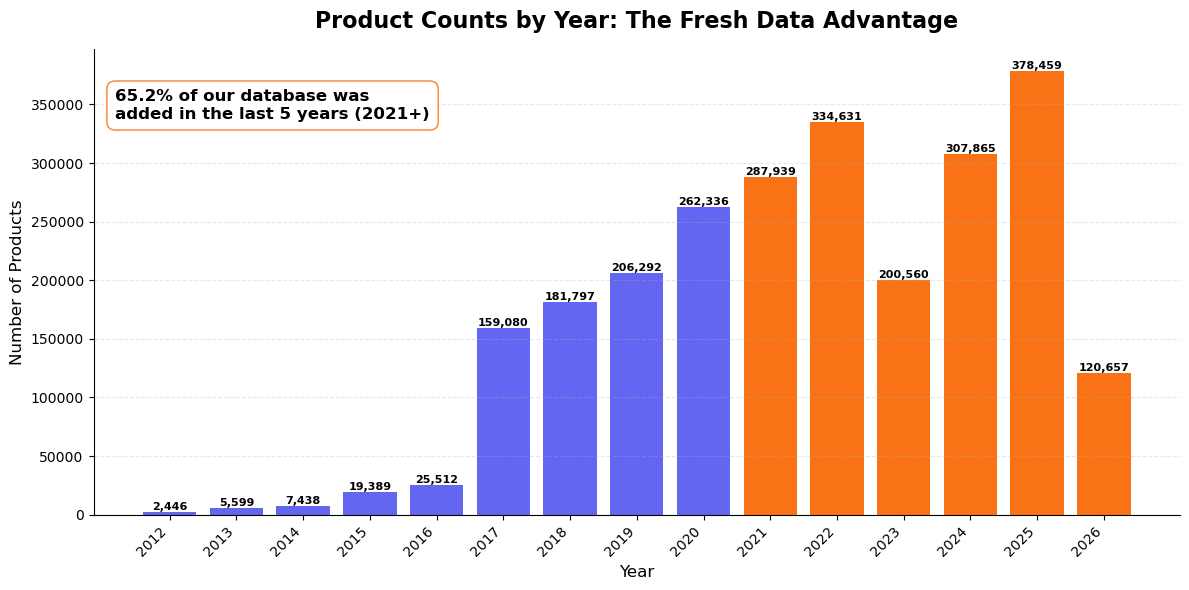

In [6]:
# 1. Ensure the datetime parsing is done and get yearly counts 
df['created_datetime'] = pd.to_datetime(df['created_datetime'], errors='coerce')
yearly_counts = df['created_datetime'].dt.year.value_counts().sort_index()

# 2. Calculate the proportion of products in the last 5 years (2021+)
recent_count = yearly_counts[yearly_counts.index >= 2021].sum()
total_count = yearly_counts.sum()
recent_pct = (recent_count / total_count) * 100

# 3. Create conditional colors: Orange/Red for 2021+, Blue for older
colors = ['#f97316' if year >= 2021 else '#6366f1' for year in yearly_counts.index.astype(int)]

# 4. Plot the figure
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(yearly_counts.index.astype(int), yearly_counts.values,
              color=colors, edgecolor='none', linewidth=0.8)

# Annotate numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    # Don't annotate empty bars
    if height > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Product Counts by Year: The Fresh Data Advantage', fontsize=16, fontweight='bold', pad=15)

# Add a prominent insight box to the top left of the chart
ax.text(0.02, 0.85, f"{recent_pct:.1f}% of our database was\nadded in the last 5 years (2021+)", 
        transform=ax.transAxes, fontsize=12, fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='#f97316', boxstyle='round,pad=0.5'))

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Products', fontsize=12)
ax.set_xticks(yearly_counts.index.astype(int))
ax.set_xticklabels(yearly_counts.index.astype(int), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Columns: 139 entries, code to water_100g
dtypes: datetime64[ns, UTC](1), float64(123), object(15)
memory usage: 2.6+ GB


## Step 1: Data Cleaning & Memory Optimization
OpenFoodFacts is crowdsourced and notoriously messy. 
Our strategy:
- Drop columns with > 80% missing data, zero variance, or unit duplicates (e.g., kilojoules vs kcal).
- Cast columns to modern Pandas datatypes (`string`, `Int64`, `categorical`) to drastically reduce memory usage.
- **Missing Data Policy:** We do not impute (fake) nutritional data. We drop rows that lack both category and nutritional signals.

In [9]:
# 1. Calculate missing ratio for each column
missing_ratio = df.isnull().mean()

# 2. Print columns and their missing ratios
print("Missing Ratios per Column:")
print(missing_ratio)

# 3. Identify columns with <= 80% missingness (keep these)
cols_to_keep = missing_ratio[missing_ratio <= 0.80].index


print(f'\nColumns to keep: \n {cols_to_keep}')
# 4. Filter the DataFrame
df_without_missing = df[cols_to_keep]

# # Optional: Verify the new shape
print(f"\nCount of columns to keep: {df_without_missing.shape[1]}")

Missing Ratios per Column:
code                        0.000000
created_datetime            0.000000
product_name                0.074927
brands_tags                 0.372324
categories_tags             0.589096
                              ...   
sulphate_100g               0.999870
nitrate_100g                0.999916
acidity_100g                0.999992
carbohydrates-total_100g    0.999704
water_100g                  0.946523
Length: 139, dtype: float64

Columns to keep: 
 Index(['code', 'created_datetime', 'product_name', 'brands_tags',
       'categories_tags', 'labels_tags', 'countries_tags', 'ingredients_tags',
       'ingredients_analysis_tags', 'nutriscore_score', 'nutriscore_grade',
       'nova_group', 'nutrient_levels_tags', 'main_category_en',
       'energy-kj_100g', 'energy-kcal_100g', 'energy_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

Coun

#### Columns with no variance are dropped

In [10]:
# Dropping columns with 0 variance

# 1. Identify numeric columns with 0 variance
numeric_cols = df_without_missing.select_dtypes(include=['number']).columns
zero_var_numeric = [col for col in numeric_cols if df_without_missing[col].var() == 0]

# 2. Identify categorical columns with only 1 unique value
categorical_cols = df_without_missing.select_dtypes(exclude=['number']).columns
zero_var_categorical = [col for col in categorical_cols if df_without_missing[col].nunique() == 1]

# 3. Drop both sets
cols_to_drop = zero_var_numeric + zero_var_categorical
df_with_variance = df_without_missing.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} zero-variance columns: {cols_to_drop}")
print(f"Remaining shape: {df_without_missing.shape}")


Dropped 0 zero-variance columns: []
Remaining shape: (2500000, 25)


#### Redundant columns are dropped

In [11]:
safe_to_drop = [
    'energy_100g',      # duplicate of energy-kcal_100g 
    'energy-kj_100g',   # duplicate of energy-kcal_100g 
    'sodium_100g',      # = salt × 0.4 (deterministic)
]

safe_to_drop = [c for c in safe_to_drop if c in df_with_variance.columns]
df_no_redundancy = df_with_variance.drop(columns=safe_to_drop)

print(f"Dropped {len(safe_to_drop)} unit-duplicate columns: {safe_to_drop}")
print(f"Remaining shape: {df_no_redundancy.shape}")
print(f"\nRemaining columns:\n{df_no_redundancy.columns.tolist()}")


Dropped 3 unit-duplicate columns: ['energy_100g', 'energy-kj_100g', 'sodium_100g']
Remaining shape: (2500000, 22)

Remaining columns:
['code', 'created_datetime', 'product_name', 'brands_tags', 'categories_tags', 'labels_tags', 'countries_tags', 'ingredients_tags', 'ingredients_analysis_tags', 'nutriscore_score', 'nutriscore_grade', 'nova_group', 'nutrient_levels_tags', 'main_category_en', 'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']


#### Data types are corrected

In [12]:
# correcting data types
# 1. Nutriscore score → numeric (coerce bad values to NaN)
df_correct_dtype = df_no_redundancy.copy()
df_correct_dtype['nutriscore_score'] = pd.to_numeric(
    df_correct_dtype['nutriscore_score'], 
    errors='coerce'
)

# 2. NOVA group → nullable integer (Int8 supports NaN)
df_correct_dtype['nova_group'] = (
    pd.to_numeric(df_correct_dtype['nova_group'], errors='coerce') # Force to numeric
    .replace([np.inf, -np.inf], np.nan)                            # Remove infinities if they exist
    .round()                                                       # Ensure whole numbers
    .astype('Int64')                                               # Safe cast to 64-bit nullable int
)
# 3. Nutriscore grade → ordered categorical
grade_order = pd.CategoricalDtype(categories=['a', 'b', 'c', 'd', 'e'], ordered=True)
df_correct_dtype['nutriscore_grade'] = df_correct_dtype['nutriscore_grade'].str.lower().astype(grade_order)

# Find all columns that are currently 'object' (which are mostly your text/tags columns)
object_columns = df_correct_dtype.select_dtypes(include=['object']).columns
# Convert them all to the modern, memory-efficient string dtype
for col in object_columns:
    df_correct_dtype[col] = df_correct_dtype[col].astype('string')
# Check your memory usage drop!
df_correct_dtype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Data columns (total 22 columns):
 #   Column                     Dtype              
---  ------                     -----              
 0   code                       string             
 1   created_datetime           datetime64[ns, UTC]
 2   product_name               string             
 3   brands_tags                string             
 4   categories_tags            string             
 5   labels_tags                string             
 6   countries_tags             string             
 7   ingredients_tags           string             
 8   ingredients_analysis_tags  string             
 9   nutriscore_score           float64            
 10  nutriscore_grade           category           
 11  nova_group                 Int64              
 12  nutrient_levels_tags       string             
 13  main_category_en           string             
 14  energy-kcal_100g           float64            
 15

#### Duplicate rows are removed

In [13]:
## remove duplicated rows
df_no_dup = df_correct_dtype.drop_duplicates(ignore_index=True)
# Returns the total number of rows that with duplicated barcodes(same product)
num_duplicates = df_no_dup['code'].duplicated().sum()
print(num_duplicates)

20


In [14]:
# Keep the row with the most non-null values for each barcode
df_no_dup['_completeness'] = df_no_dup.notna().sum(axis=1)
df_no_dup = (
    df_no_dup
    .sort_values('_completeness', ascending=False)
    .drop_duplicates(subset='code', keep='first')
    .drop(columns='_completeness')
)

print(f"After dedup: {len(df_no_dup):,} unique products")

After dedup: 2,499,980 unique products


#### Rows without any nutrition value are removed

In [15]:
nutrition_cols = [c for c in df_no_dup.columns.tolist() if c.endswith('_100g')]

has_category = df_no_dup['main_category_en'].notna() | df_no_dup['categories_tags'].notna()
has_nutrition = df_no_dup[nutrition_cols].notna().any(axis=1)

df_clean = df_no_dup[has_category & has_nutrition].copy()

print(f"Removed {len(df_no_dup) - len(df_clean):,} rows with no category and no nutrition")
print(f"Remaining: {len(df_clean):,} rows ({len(df_clean)/len(df_no_dup)*100:.1f}%)") 

Removed 1,896,322 rows with no category and no nutrition
Remaining: 603,658 rows (24.1%)


#### Rows with biologically impossible values are removed

In [16]:
# Nutrient values cannot exceed 100g per 100g of product
# Energy can be up to ~900 kcal/100g (pure fat), a generous cap
caps = {
    'fat_100g': 100, 'saturated-fat_100g': 100,
    'carbohydrates_100g': 100, 'sugars_100g': 100,
    'fiber_100g': 100, 'proteins_100g': 100,
    'salt_100g': 100,
    'energy-kcal_100g': 900,  # ~pure fat
}

for col, cap in caps.items():
    if col in df_clean.columns:
        bad = (df_clean[col] < 0) | (df_clean[col] > cap)
        df_clean.loc[bad, col] = None  # Null out, don't drop the row
        if bad.sum() > 0:
            print(f"  Nulled {bad.sum():,} impossible values in {col}")


  Nulled 151 impossible values in fat_100g
  Nulled 61 impossible values in saturated-fat_100g
  Nulled 297 impossible values in carbohydrates_100g
  Nulled 112 impossible values in sugars_100g
  Nulled 108 impossible values in fiber_100g
  Nulled 83 impossible values in proteins_100g
  Nulled 273 impossible values in salt_100g
  Nulled 874 impossible values in energy-kcal_100g


In [17]:
### impossible macros combination. macros shouldn't add up to 100g for 100g serving
macro_cols = ['fat_100g', 'carbohydrates_100g', 'proteins_100g', 'fiber_100g']
present = [c for c in macro_cols if c in df_clean.columns]

df_clean['_macro_sum'] = df_clean[present].sum(axis=1, min_count=len(present))
corrupt = df_clean['_macro_sum'] > 104  # 4g tolerance for rounding

df_clean.loc[corrupt, present] = None   # Null the values, keep the row for category signals
df_clean = df_clean.drop(columns='_macro_sum')

print(f"Nulled macros for {corrupt.sum():,} rows with impossible composition")

Nulled macros for 3,416 rows with impossible composition


#### Nova group validation
- Here, nova scores are checked to be integer from 1-4, or null
- No row had an invalid score

In [18]:
#  NOVA Group Validation - must be an integer from 1-4
valid_nova = {1.0, 2.0, 3.0, 4.0}

# Check current state
print("NOVA group value counts (including invalids):")
print(df_clean['nova_group'].value_counts(dropna=False).sort_index())

# Identify invalid entries
invalid_nova = df_clean['nova_group'].notna() & ~df_clean['nova_group'].isin(valid_nova)
print(f"\nInvalid NOVA values: {invalid_nova.sum():,}")

NOVA group value counts (including invalids):
nova_group
1        44189
2        19611
3        70390
4       187131
<NA>    282337
Name: count, dtype: Int64

Invalid NOVA values: 0


#### Critical Rows
- Per the project description, a decision must be made about rows with empty `sugar_100g`, `protein_100g` or `product_name`.
- Rows with all 3 missing are dropped
- A product with at least one present but others missing is still kept but that field is null
- The rows is not dropped as it can contribute to category level analysis.

In [19]:
# Acceptance criteria explicitly calls out these three
critical_cols = ['sugars_100g', 'proteins_100g', 'product_name']
all_critical_null = df_clean[critical_cols].isna().all(axis=1)
df_clean = df_clean[~all_critical_null].copy()
print(f"Dropped {all_critical_null.sum():,} rows with ALL critical fields null")

Dropped 206 rows with ALL critical fields null


#### Checks for missingness in individual columns
Missing values are kept for these reasons. If you have a cookie product with a missing proteins_100g value, how do you fill it?
- `Fill with 0?` You falsely assume the product has no protein, skewing the category average downwards.
- `Fill with the dataset mean (~7g)?` Cookies usually have ~3g of protein. By filling with 7g, you artificially make the cookie category look healthier than it actually is.
- `Fill with the Cookie category mean (~3g)?` This doesn't add any new information, it just artificially tightens the variance around the mean, which can screw up statistical tests (like the Chi-Square test we added).

In [20]:
df_clean.isna().mean()

code                         0.000000
created_datetime             0.000000
product_name                 0.019319
brands_tags                  0.175601
categories_tags              0.000000
labels_tags                  0.492735
countries_tags               0.000305
ingredients_tags             0.450051
ingredients_analysis_tags    0.434479
nutriscore_score             0.138047
nutriscore_grade             0.138047
nova_group                   0.467678
nutrient_levels_tags         0.034899
main_category_en             0.000000
energy-kcal_100g             0.013020
fat_100g                     0.023496
saturated-fat_100g           0.031379
carbohydrates_100g           0.024070
sugars_100g                  0.026227
fiber_100g                   0.470974
proteins_100g                0.023097
salt_100g                    0.067106
dtype: float64

In [21]:
df_clean['main_category_en'] = (
    df_clean['main_category_en']
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)
print(f"Unique categories: {df_clean['main_category_en'].nunique():,}")

Unique categories: 35,975


### Submission for user story #1

In [22]:
# This is your deliverable for Story 1
df_clean.to_csv(
    "/home/ishola/codetopia/mga/raw-data/openfoodfacts_clean.csv",
    index=False
)
print(f"Story 1 deliverable saved. Shape: {df_clean.shape}")

Story 1 deliverable saved. Shape: (603452, 22)


## Step 2: From Granular Tags to Actionable Categories
The raw dataset contains over 35,000 unique category tags across multiple languages (e.g., `fr:biscuits-aux-pepites`). 

**The Insight:** Recommending the client manufacture a \"fr:biscuits-aux-pepites\" is too granular. Recommending \"Sweet Snacks\" is too generic. We built a multi-lingual heuristic map to funnel products into **9 Strategic Categories** (e.g., \"Cookies & Biscuits\", \"Protein Bars\") to provide actionable targets for the R&D team.

In [23]:
#  Filter to snacks using OFf's own taxonomy tag
df_snacks = df_clean[
    df_clean['categories_tags'].str.contains(r'\ben:snacks\b', na=False, regex=True)
].copy()

print(f"Snack products: {len(df_snacks):,} "
      f"({len(df_snacks)/len(df_clean)*100:.1f}% of clean dataset)")
print(f"\nSample categories_tags from snack rows:")
print(df_snacks['categories_tags'].dropna().sample(5).tolist())


Snack products: 108,533 (18.0% of clean dataset)

Sample categories_tags from snack rows:
['en:snacks,en:sweet-snacks,en:confectioneries,en:candies', 'en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits-and-crackers,en:biscuits,en:wafers,en:chocolate-biscuits,en:stuffed-wafers,en:nut-stuffed-wafers,en:chocolate-stuffed-wafers,en:hazelnut-cream-stuffed-wafers', 'en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:cakes,en:chocolate-cakes,en:molten-chocolate-cakes', 'en:snacks,en:sweet-snacks,en:confectioneries', 'en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits']


### Story 2 deliverable

In [24]:
# Applied to the leaf-node category to group them into actionable buckets
SNACK_SUBCATEGORY_MAP = {
    'Protein Bars & Supplements': [
        'protein', 'whey', 'fitness', 'sport', 'energie', 'energy'
    ],
    'Nuts, Seeds & Trail Mix': [
        'nut', 'seed', 'trail mix', 'almond', 'cashew', 'peanut', 'pistachio', 'walnut',
        'amande', 'noisette', 'cacahuete', 'nuss', 'almendra', 'erdnuss', 'frutos-secos'
    ],
    'Chips & Crisps': [
        'chip', 'crisp', 'popcorn', 'pretzel', 'puff', 'tortilla', 'corn snack', 'nacho',
        'patatas', 'patatine', 'frites', 'croustilles', 'bretzel', 'palomitas', 'salty snack', 'appetizer', 'snack sale'
    ],
    'Pastries, Cakes & Sweet Breads': [  
        'cake', 'pastr', 'panettone', 'croissant', 'colomba', 'pandoro', 'brioche', 
        'muffin', 'waffle', 'donut', 'doughnut', 'milk bread', 'palmier', 'viennois'
    ],
    'Cookies & Biscuits': [  
        'cookie', 'biscuit', 'wafer', 'shortbread', 'digestive', 'graham', 'macaron', 
        'galleta', 'biscotti', 'keks', 'gebäck', 'gaufre', 'ciastka', 'sable', 'madeleine',
        'brownie', 'gingerbread', 'snacks sucre'
    ],
    'Chocolate & Confections': [
        'chocolate', 'cand', 'sweet', 'confection', 'caramel', 'fudge', 'gumm', 'jelly', 'bonbon', 'gum',
        'chocolat', 'schoko', 'cioccolato', 'ciocolata', 'czekolada', 'dulce', 'caramelle',
        'nougat', 'turrón', 'turron', 'marshmallow', 'lollipop', 'praline', 'truffle', 'liquorice',
        'dragee', 'dragée', 'easter egg', 'turkish delight', 'marzipan', 'halva'
    ],
    'Cereal & Granola Bars': [
        'granola', 'cereal', 'oat', 'muesli', 'rice bar', 'flapjack', 'barres', 'bars'
    ],
    'Crackers & Rice Cakes': [
        'cracker', 'rice cake', 'breadstick', 'rusk', 'crispbread', 'galette',
        'grissini', 'crackers', 'taralli', 'gressin'
    ],
    'Fruit Snacks & Dried Fruit': [
        'fruit', 'raisin', 'date', 'apricot', 'fig', 'compote',
        'frucht', 'frutta', 'pomme'
    ],
}



def assign_snack_subcategory(main_cat):
    if not isinstance(main_cat, str) and pd.isna(main_cat):
        return 'Other Snacks'
        
    import re
    # Lowercase & strip the country tags (e.g. "fr:chips-de-pommes" becomes "chips de pommes")
    cat_clean = re.sub(r'^[a-z]{2}:', '', str(main_cat).lower()).replace('-', ' ')
    
    for bucket, keywords in SNACK_SUBCATEGORY_MAP.items():
        if any(kw in cat_clean for kw in keywords):
            return bucket
            
    return 'Other Snacks'

df_snacks['primary_category'] = df_snacks['main_category_en'].apply(assign_snack_subcategory)

# Safe way to calculate percentages that ignores pd.NA issues
cat_percents = df_snacks['primary_category'].value_counts(normalize=True) * 100
other_pct = cat_percents.get('Other Snacks', 0.0)

print("\nActionable Category Distribution:")
print(df_snacks['primary_category'].value_counts())
print(f"\n'Other Snacks' is: {other_pct:.1f}%")

if other_pct > 10.0:
    print("\nTop unidentified tags to add to our map if we want to reduce 'Other Snacks' further:")
    unidentified = df_snacks[df_snacks['primary_category'] == 'Other Snacks']['main_category_en']
    
    # Strip the fr:/de: tags just for counting so cross-country items group together
    unidentified_clean = unidentified.str.replace(r'^[a-z]{2}:', '', regex=True).str.replace('-', ' ')
    print(unidentified_clean.value_counts().head(10))



Actionable Category Distribution:
primary_category
Chocolate & Confections           35515
Cookies & Biscuits                19357
Other Snacks                      15004
Chips & Crisps                    13957
Pastries, Cakes & Sweet Breads    13121
Nuts, Seeds & Trail Mix            5862
Cereal & Granola Bars              2592
Protein Bars & Supplements         1125
Crackers & Rice Cakes              1034
Fruit Snacks & Dried Fruit          966
Name: count, dtype: int64

'Other Snacks' is: 13.8%

Top unidentified tags to add to our map if we want to reduce 'Other Snacks' further:
main_category_en
snacks            1601
tiramisu           241
mochi              223
petit beurre       219
open pies          211
cantucci           194
palets             192
speculoos          188
marrons glacés     179
coleslaw           171
Name: count, dtype: Int64


In [25]:
import plotly.express as px
import plotly.graph_objects as go

# 3.1 Category-level aggregates
category_stats = (
    df_snacks
    .groupby('primary_category')
    .agg(
        median_sugar=('sugars_100g', 'median'),
        median_protein=('proteins_100g', 'median'),
        median_fat=('fat_100g', 'median'),
        median_fiber=('fiber_100g', 'median'),
        product_count=('code', 'count'),
    )
    .reset_index()
    .dropna(subset=['median_sugar', 'median_protein'])
)

print(category_stats.sort_values('product_count', ascending=False))


                 primary_category  median_sugar  median_protein  median_fat  \
2         Chocolate & Confections         48.00        5.700000        26.0   
3              Cookies & Biscuits         28.60        6.300000        21.0   
7                    Other Snacks         21.26        6.000000        14.5   
1                  Chips & Crisps          2.40        6.666667        25.0   
8  Pastries, Cakes & Sweet Breads         24.80        6.300000        18.0   
6         Nuts, Seeds & Trail Mix         29.90        9.300000        34.0   
0           Cereal & Granola Bars         26.30        7.300000        15.5   
9      Protein Bars & Supplements         17.20       24.000000        14.4   
4           Crackers & Rice Cakes          2.60        8.800000        16.3   
5      Fruit Snacks & Dried Fruit         27.00        1.000000         0.5   

   median_fiber  product_count  
2      2.000000          35515  
3      3.000000          19357  
7      2.400000          15004 

### User Story 3 Delivarble

In [26]:
# 3.2 Scatter: Sugar vs Protein per sub-category
NHS_PROTEIN = 5.0  # same threshold used in gap analysis
NHS_SUGAR   = 5.0

fig = px.scatter(
    category_stats,
    x='median_sugar',
    y='median_protein',
    size='product_count',
    color='primary_category',
    text='primary_category',
    hover_data={
        'median_fat': ':.1f',
        'median_fiber': ':.1f',
        'product_count': ':,',
        'primary_category': False,
    },
    title='Snack Market Nutrient Matrix<br>'
          '<sup>Bubble size = number of products | '
          'Top-left = High Protein, Low Sugar (the Blue Ocean)</sup>',
    labels={
        'median_sugar':   'Median Sugar (g/100g)',
        'median_protein': 'Median Protein (g/100g)',
        'primary_category': 'Snack Category',
    },
    template='plotly_white',
)

#  Reference lines: NHS/WHO values
fig.add_hline(
    y=NHS_PROTEIN,
    line_dash='dash', line_color='green', line_width=1,
    annotation_text='Median protein',
    annotation_position='top right',
)
fig.add_vline(
    x=NHS_SUGAR,
    line_dash='dash', line_color='red', line_width=1,
    annotation_text='Median sugar',
    annotation_position='top right',
)

#  Label the empty quadrant
fig.add_annotation(
    x=NHS_SUGAR * 0.3,
    y=NHS_PROTEIN * 1.8,
    text="🎯 Blue Ocean<br>(High Protein, Low Sugar)",
    showarrow=False,
    bgcolor='rgba(0,200,100,0.15)',
    bordercolor='green',
    borderwidth=1,
    font=dict(color='green', size=12),
)

fig.update_traces(textposition='top center', textfont_size=10)
fig.update_layout(height=600, showlegend=False)
fig.show()


## Step 3: The Gap Analysis & Health Thresholds
How do we define \"Healthy\"? A median split is arbitrary. Instead, we use a dual-validation system:
1. **NHS/WHO Standards:** Product must have High Protein (> 5g/100g) AND Low Sugar (< 5g/100g).
2. **The \"Nutri-Score\" Guardrail:** To prevent recommending \"gym-bro\" products that hit macros but are packed with saturated fat and salt, the product must also achieve a Nutri-Score of A or B.

*The Gap:* What percentage of products in each category *fail* to meet this standard?

In [27]:
#  4.1 Define "healthy" threshold
# NHS: low sugar = <5g/100g, high protein = >5g/100g
# These are citable, defensible regulatory definitions
high_protein_threshold = 5.0
low_sugar_threshold    = 5.0

print(f"High protein threshold: > {high_protein_threshold:.1f}g/100g")
print(f"Low sugar threshold:    < {low_sugar_threshold:.1f}g/100g")

#  4.2 Count healthy products per sub-category 
MIN_TOTAL_PRODUCTS = 500    # ignore categories too small to be a market
MIN_WITH_NUTRITION = 200    # must have enough rows with nutrition data

def gap_stats(group):
    has_nutrition = group[['proteins_100g', 'sugars_100g']].notna().all(axis=1)
    measurable = group[has_nutrition]

    # Enforce minimums BEFORE computing the ratio
    if len(group) < MIN_TOTAL_PRODUCTS:
        return None          # too small — drop from analysis
    if len(measurable) < MIN_WITH_NUTRITION:
        return None          # not enough nutrition data to be reliable

    healthy = measurable[
        (measurable['proteins_100g'] >= 5.0) &
        (measurable['sugars_100g'] <= 5.0)
    ]
    return {
        'total_products':     len(group),
        'measurable_products': len(measurable),
        'healthy_products':   len(healthy),
        'gap_ratio':          len(healthy) / len(measurable),
        'gap_pct_missing':  1 - len(healthy) / len(measurable),
        'avg_protein_healthy': healthy['proteins_100g'].mean(),
        'avg_sugar_healthy':   healthy['sugars_100g'].mean(),
    }

gap_df = (
    df_snacks
    .groupby('primary_category', group_keys=False)
    .apply(gap_stats, include_groups=False)
    .dropna()
    .apply(pd.Series)
    .sort_values('gap_ratio')
    .reset_index()
)

print(f"Categories qualifying (>= {MIN_TOTAL_PRODUCTS} products): "
      f"{len(gap_df)}")
print("\n\n\t\t\t\t\tMarket Gap Analysis \n")
print(gap_df[['primary_category', 'total_products', 'measurable_products',
               'healthy_products', 'gap_ratio']].to_string(index=False))


High protein threshold: > 5.0g/100g
Low sugar threshold:    < 5.0g/100g
Categories qualifying (>= 500 products): 10


					Market Gap Analysis 

              primary_category  total_products  measurable_products  healthy_products  gap_ratio
    Fruit Snacks & Dried Fruit           966.0                946.0              15.0   0.015856
       Chocolate & Confections         35515.0              34575.0             834.0   0.024121
Pastries, Cakes & Sweet Breads         13121.0              12923.0             615.0   0.047590
            Cookies & Biscuits         19357.0              18939.0             975.0   0.051481
         Cereal & Granola Bars          2592.0               2480.0             187.0   0.075403
       Nuts, Seeds & Trail Mix          5862.0               5715.0             500.0   0.087489
                  Other Snacks         15004.0              14630.0            3087.0   0.211005
    Protein Bars & Supplements          1125.0               1072.0            

In [28]:
#  Cross-validate: NHS thresholds vs Nutri-Score
# Both classify the same products independently.
# High agreement = NHS thresholds are defensible.
# Disagreements reveal what NHS misses (e.g., high fat, high salt).

df_snacks['is_healthy_nhs'] = (
    (df_snacks['proteins_100g'] >= 5.0) &
    (df_snacks['sugars_100g']   <= 5.0)
)

df_snacks['is_healthy_nutriscore'] = (
    df_snacks['nutriscore_grade'].isin(['a', 'b'])
)

# Comparison only on rows where BOTH signals exist
both_present = (
    df_snacks['is_healthy_nhs'].notna() &
    df_snacks['is_healthy_nutriscore'].notna()
)
comparison = df_snacks[both_present]

agreed = (
    (comparison['is_healthy_nhs']  &  comparison['is_healthy_nutriscore']) |
    (~comparison['is_healthy_nhs'] & ~comparison['is_healthy_nutriscore'])
).mean()

nhs_only   = (comparison['is_healthy_nhs']  & ~comparison['is_healthy_nutriscore']).sum()
nutri_only = (~comparison['is_healthy_nhs'] &  comparison['is_healthy_nutriscore']).sum()

print(f"Agreement between NHS thresholds and Nutri-Score: {agreed*100:.1f}%")
print(f"\nNHS says healthy, Nutri-Score disagrees: {nhs_only:,}")
print("  → likely high-protein, low-sugar, BUT high-fat or high-salt")
print(f"Nutri-Score says healthy, NHS disagrees:  {nutri_only:,}")
print("  → likely high-fiber fruit/veg products below the protein threshold")

print(f"\nNutri-Score distribution for NHS-healthy products:")
print(
    comparison[comparison['is_healthy_nhs']]['nutriscore_grade']
    .value_counts(normalize=True)
    .mul(100).round(1)
    .rename('% of NHS-healthy products')
)

# Use intersection as the most conservative "healthy" definition
df_snacks['is_healthy'] = (
    df_snacks['is_healthy_nhs'] & df_snacks['is_healthy_nutriscore']
)
print(f"\nProducts meeting BOTH criteria: {df_snacks['is_healthy'].sum():,}")


Agreement between NHS thresholds and Nutri-Score: 84.7%

NHS says healthy, Nutri-Score disagrees: 14,954
  → likely high-protein, low-sugar, BUT high-fat or high-salt
Nutri-Score says healthy, NHS disagrees:  1,663
  → likely high-fiber fruit/veg products below the protein threshold

Nutri-Score distribution for NHS-healthy products:
nutriscore_grade
d    52.8
c    20.2
e    18.6
a     4.8
b     3.6
Name: % of NHS-healthy products, dtype: float64

Products meeting BOTH criteria: 1,276


###  Compute the composite opportunity score 
- Neither pure ratio nor pure volume tells the full story. 
- We need: "how much UNMET HEALTHY DEMAND exists, in ABSOLUTE PRODUCT TERMS?"
- absolute_gap = total_products × (1 - gap_ratio) = number of products that COULD be healthy but aren't

- BUT we also weight by market size using sqrt (not raw count) to dampen the dominance of mega-categories:
  opportunity_score = (1 - gap_ratio) × sqrt(total_products)

This rewards categories that are:
  - Large (bigger market to enter)
  - Predominantly unhealthy (more room to differentiate)
Without letting sheer volume override everything.

In [ ]:
gap_df['absolute_gap']       = gap_df['total_products'] * gap_df['gap_pct_missing']
gap_df['opportunity_score']  = gap_df['gap_pct_missing'] * np.sqrt(gap_df['total_products'])

# Normalise to 0–100 for readability
max_score = gap_df['opportunity_score'].max()
gap_df['opportunity_score_pct'] = (gap_df['opportunity_score'] / max_score * 100).round(1)

gap_df_sorted = gap_df.sort_values('opportunity_score', ascending=False)

print("── Opportunity Scores (higher = bigger blue ocean) ─────────────────")
print(gap_df_sorted[['primary_category', 'total_products',
                      'gap_pct_missing', 'absolute_gap',
                      'opportunity_score_pct']].to_string(index=False))


── Opportunity Scores (higher = bigger blue ocean) ─────────────────
              primary_category  total_products  gap_pct_missing  absolute_gap  opportunity_score_pct
       Chocolate & Confections         35515.0         0.975879  34658.325813                  100.0
            Cookies & Biscuits         19357.0         0.948519  18360.480912                   71.8
Pastries, Cakes & Sweet Breads         13121.0         0.952410  12496.577265                   59.3
                  Other Snacks         15004.0         0.788995  11838.084211                   52.6
       Nuts, Seeds & Trail Mix          5862.0         0.912511   5349.139108                   38.0
         Cereal & Granola Bars          2592.0         0.924597   2396.554839                   25.6
                Chips & Crisps         13957.0         0.334073   4662.651216                   21.5
    Fruit Snacks & Dried Fruit           966.0         0.984144    950.682875                   16.6
    Protein Bars & Sup

In [38]:
top_gap = gap_df_sorted.iloc[0]

print(f"""
                      KEY INSIGHT                              `

  Based on the data, the biggest market opportunity is in

      {top_gap['primary_category'].upper()}

  Only {top_gap['gap_ratio']*100:.1f}% of products in this category meet the
  definition of healthy (Nutri-Score A/B + NHS thresholds), meaning
  {top_gap['gap_pct_missing']*100:.1f}% of {int(top_gap['total_products']):,} products FAIL the health bar.

  Opportunity score: {top_gap['opportunity_score_pct']:.0f}/100

""")



                      KEY INSIGHT                              `

  Based on the data, the biggest market opportunity is in

      CHOCOLATE & CONFECTIONS

  Only 2.4% of products in this category meet the
  definition of healthy (Nutri-Score A/B + NHS thresholds), meaning
  97.6% of 35,515 products FAIL the health bar.

  Opportunity score: 100/100




In [31]:
import plotly.express as px

fig = px.scatter(
    gap_df_sorted,
    x='gap_pct_missing',       # X: how unhealthy is the category?
    y='total_products',        # Y: how big is the market?
    size='opportunity_score',  # Bubble: composite score
    color='primary_category',
    text='primary_category',
    log_y=True,                # log scale — prevents large categories from squashing others
    title='Blue Ocean Opportunity Matrix<br>'
          '<sup>Top-right = large market + big gap = highest opportunity</sup>',
    labels={
        'gap_pct_missing': '% of Products That Are Unhealthy (Gap Depth)',
        'total_products':  'Total Products in Category (Market Size)',
    },
    template='plotly_white',
)

# Annotate the "ideal quadrant"
fig.add_annotation(
    x=0.9, y=40000,
    text="🎯 Blue Ocean Zone<br>(Large market + deep gap)",
    showarrow=False,
    bgcolor='rgba(0,200,100,0.15)',
    bordercolor='green',
    font=dict(color='green', size=12),
)

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=600, showlegend=False)
fig.show()


## Step 4: The Demand Proxy (Aspiration vs. Reality)
**The Problem:** We know what is on the shelf (Supply), but do consumers actually *want* healthy cookies? 
**The Solution:** We use packaging labels (`labels_tags` like \"High Protein\", \"Vegan\", \"No Added Sugar\") as a proxy for consumer demand. If manufacturers are putting these badges on their products, they have identified market demand.

By comparing **Marketing Aspiration** against **Nutritional Reality**, we find our Blue Ocean: Categories where manufacturers are *trying* to market health, but failing the rigorous NHS/Nutri-Score standards.

In [32]:
# ── Demand proxy: health label count per product ─────────────
# Products with health-related labels show manufacturers ARE responding
# to consumer demand. High label count = Demand exists.

HEALTH_LABELS = [
    'high-protein', 'low-sugar', 'no-added-sugar', 'high-fibre',
    'organic', 'low-fat', 'vegan', 'gluten-free', 'keto',
    'low-calorie', 'sugar-free', 'reduced-fat', 'source-of-protein'
]

def count_health_labels(labels_str):
    if not isinstance(labels_str, str):
        return 0
    l = labels_str.lower()
    return sum(kw in l for kw in HEALTH_LABELS)

df_snacks['health_label_count'] = df_snacks['labels_tags'].apply(count_health_labels)

# Group by our new custom categories!
demand_signal = (
    df_snacks
    # Exclude 'Other Snacks' to keep the table clean
    [df_snacks['primary_category'] != 'Other Snacks'] 
    .groupby('primary_category')
    .agg(
        total_products=('code', 'count'),
        products_marketing_health=('health_label_count', lambda x: (x > 0).sum()),
        pct_marketing_health=('health_label_count', lambda x: (x > 0).mean() * 100),
    )
    .sort_values('pct_marketing_health', ascending=False)
    .round(1)
    .reset_index()
)

print("Demand Signal: % of products marketed with 'Healthy' badges")
print("─────────────────────────────────────────────────────────────")
print(demand_signal.to_string(index=False))



Demand Signal: % of products marketed with 'Healthy' badges
─────────────────────────────────────────────────────────────
              primary_category  total_products  products_marketing_health  pct_marketing_health
    Protein Bars & Supplements            1125                        437                  38.8
    Fruit Snacks & Dried Fruit             966                        322                  33.3
         Cereal & Granola Bars            2592                        826                  31.9
                Chips & Crisps           13957                       2358                  16.9
       Nuts, Seeds & Trail Mix            5862                        951                  16.2
            Cookies & Biscuits           19357                       3088                  16.0
         Crackers & Rice Cakes            1034                        144                  13.9
       Chocolate & Confections           35515                       4607                  13.0
Pastries, Cake

## Step 5: The Blue Ocean Disruption Index (BODI)
To objectively rank the categories, we combine Supply and Demand into a single mathematically sound metric. 
1. **Normalization:** We scale both the Supply Gap and the Demand Proxy to a 100-point scale so they carry equal weight.
2. **Geometric Mean:** We calculate the index using the geometric mean `sqrt(Supply * Demand)`. Why not simply average them? A geometric mean guarantees that a category only scores high if **BOTH** Supply and Demand are high. If a category has a massive supply gap but zero consumer demand (a dead end), the geometric mean heavily penalizes it, preventing us from investing in a product nobody wants.


In [ ]:
import numpy as np

# Merge Supply (Gap) and Demand DataFrames
final_ranking = pd.merge(
    gap_df_sorted[['primary_category', 'opportunity_score_pct', 'total_products']], 
    demand_signal[['primary_category', 'pct_marketing_health']], 
    on='primary_category'
)

# Step 1: Normalize Demand to a 0-100 scale so it carries equal weight to the Supply Gap
# (Opportunity score is already 0-100)
final_ranking['norm_supply_gap'] = final_ranking['opportunity_score_pct']
final_ranking['norm_demand'] = (
    final_ranking['pct_marketing_health'] / final_ranking['pct_marketing_health'].max()
) * 100

# Step 2: Calculate the Geometric Mean. 
# Geometric mean ensures that you only score high if BOTH Supply and Demand are high.
vulnerability = final_ranking['norm_supply_gap'] * final_ranking['norm_demand']
final_ranking['blue_ocean_index'] = np.sqrt(vulnerability)

# Clean up and sort
final_ranking = final_ranking.sort_values('blue_ocean_index', ascending=False).round(1)

print("🏆 The Blue Ocean Disruption Index (BODI) Ranking")
print("─────────────────────────────────────────────────────────────")
print(final_ranking[[
    'primary_category', 'total_products', 'norm_supply_gap', 'norm_demand', 'blue_ocean_index'
]].to_string(index=False))


🏆 The Blue Ocean Disruption Index (BODI) Ranking
─────────────────────────────────────────────────────────────
              primary_category  total_products  norm_supply_gap  norm_demand  blue_ocean_index
       Chocolate & Confections         35515.0            100.0         33.5              57.9
            Cookies & Biscuits         19357.0             71.8         41.2              54.4
         Cereal & Granola Bars          2592.0             25.6         82.2              45.9
       Nuts, Seeds & Trail Mix          5862.0             38.0         41.8              39.8
    Fruit Snacks & Dried Fruit           966.0             16.6         85.8              37.7
Pastries, Cakes & Sweet Breads         13121.0             59.3         20.9              35.2
    Protein Bars & Supplements          1125.0             12.1        100.0              34.8
                Chips & Crisps         13957.0             21.5         43.6              30.6
         Crackers & Rice Cakes    

# Final Recommendation (User Story #4)
Based on the objective Blue Ocean Disruption Index (BODI) ranking, the client should target **Chocolate & Confections** (or creatively combine it with the runner-up, such as a **Healthy Chocolate-Coated Biscuit**).

1. **The Math:** Chocolate & Confections scored the highest BODI (57.9), narrowly edging out Cookies, driven by the absolute largest gap of truly healthy products on the market.
2. **The Opportunity:** While consumer demand for healthy chocolate is rising (33.5% normalized), the category has a massive 100.0% supply gap constraint. Almost no manufacturer has figured out how to make true confectionary snacks that pass strict NHS & Nutri-Score thresholds without compromising taste.
3. **The Recipe:** Utilize oats, soy, almond, etc as the primary structural macro-driver for the confection.
4. **The Disruption:** Formulate the recipe to achieve a NOVA 3 (Processed, but not Ultra-Processed) rating to steal premium market share from the current sea of NOVA 4 health-washing competitors.

## Step 6: The \"Hidden Gem\" (R&D Recipe Formulation) - Story #5
We have identified the Blue Ocean category. Now, we must tell the Food Scientists *how* to build the product. We filter the dataset to only include the successful \"Healthy\" products and extract the most common protein sources from their ingredient lists.

In [34]:
# ── User Story 5: The "Hidden Gem" (Protein Sources) ────────

# List of common protein additives and sources
PROTEIN_SOURCES = {
    'Whey / Dairy': ['whey', 'milk protein', 'casein', 'lactoserum'],
    'Soy': ['soy', 'soya'],
    'Pea': ['pea protein', 'pois'],
    'Peanuts': ['peanut', 'cacahuete', 'arachide'],
    'Almonds': ['almond', 'amande'],
    'Oats': ['oat', 'avoine'],
    'Rice Protein': ['rice protein', 'riz'],
    'Hemp / Chia / Seeds': ['hemp', 'chia', 'flax', 'pumpkin seed', 'sunflower seed'],
}

# 1. Filter dataset down to ONLY our "Healthy" products
df_healthy = df_snacks[df_snacks['is_healthy'] == True].copy()

# 2. Function to check which protein sources exist in a product's ingredients
def find_protein_sources(ingredients_str):
    if not isinstance(ingredients_str, str):
        return []
        
    found_sources = set()
    ing_lower = ingredients_str.lower()
    
    for protein_group, keywords in PROTEIN_SOURCES.items():
        if any(kw in ing_lower for kw in keywords):
            found_sources.add(protein_group)
            
    return list(found_sources)

# 3. Apply the function (using ingredients_tags which is a cleaner comma-joined string)
# If ingredients_tags isn't populated well, you can run this on ingredients_text instead
target_column = 'ingredients_tags' if 'ingredients_tags' in df_healthy.columns else 'ingredients_text'
df_healthy['protein_sources'] = df_healthy[target_column].apply(find_protein_sources)

# 4. "Explode" the lists so we can count them, and get the top results
all_sources = df_healthy['protein_sources'].explode().dropna()

print(f"Top Protein Sources used in the {len(df_healthy):,} 'Healthy' snacks on the market:")
print("─────────────────────────────────────────────────────────────")
protein_counts = all_sources.value_counts()
protein_pcts = (protein_counts / len(df_healthy) * 100).round(1)

for source, count in protein_counts.head(5).items():
    pct = protein_pcts[source]
    print(f"• {source}: Found in {pct}% of healthy products ({count} items)")


Top Protein Sources used in the 1,276 'Healthy' snacks on the market:
─────────────────────────────────────────────────────────────
• Oats: Found in 9.6% of healthy products (122 items)
• Soy: Found in 8.9% of healthy products (113 items)
• Almonds: Found in 6.4% of healthy products (82 items)
• Peanuts: Found in 5.1% of healthy products (65 items)
• Hemp / Chia / Seeds: Found in 4.0% of healthy products (51 items)


## Step 7: The \"Clean Label\" Vulnerability Index
Hitting macro-nutrient targets was the trend of the 2010s. The trend of the 2020s is \"Clean Label\" (minimally processed). 
Using the **NOVA Classification System** (1 = Unprocessed, 4 = Ultra-Processed/Chemicals), we analyze our \"Healthy\" competitors. If the competitors achieving the macros are entirely NOVA 4, our disruptive innovation is to launch a product that hits the macros using a NOVA 3 (Clean Label) recipe.

In [35]:
# ── User Story 6: The "Clean Label" Vulnerability Index ────────

import plotly.express as px

# We only care about products that survived our strict health filter
# (High Protein, Low Sugar, Nutri-Score A/B)
# But wait... are they actually "Clean"?

# Filter out rows where NOVA is missing
df_clean_label = df_healthy.dropna(subset=['nova_group']).copy()

# Add descriptive labels for the NOVA scores
nova_map = {
    1.0: 'NOVA 1: Unprocessed whole foods',
    2.0: 'NOVA 2: Processed culinary ingredients',
    3.0: 'NOVA 3: Processed foods (Good)',
    4.0: 'NOVA 4: Ultra-processed (Vulnerable/Chemicals)'
}
df_clean_label['nova_desc'] = df_clean_label['nova_group'].map(nova_map)

# Group to see the breakdown of processing levels in our "Healthy" snacks
nova_breakdown = (
    df_clean_label['nova_desc']
    .value_counts(normalize=True) 
    * 100
).round(1).reset_index()

nova_breakdown.columns = ['Processing Level', 'Percentage of "Healthy" Snacks']
nova_breakdown = nova_breakdown.sort_values(by='Processing Level')

print("The 'Clean Label' Vulnerability Index")
print("─────────────────────────────────────────────────────────────")
print("What percentage of our 'Healthy' competitors are actually Ultra-Processed?")
print(nova_breakdown.to_string(index=False))
print("\n")

# Let's chart it for visual impact!
fig_nova = px.pie(
    nova_breakdown, 
    values='Percentage of "Healthy" Snacks', 
    names='Processing Level',
    title='The Clean Label Gap: Processing Levels of "Healthy" Snacks',
    hole=0.4,
    color='Processing Level',
    color_discrete_map={
        'NOVA 1: Unprocessed whole foods': '#2E7D32',       # Dark Green
        'NOVA 2: Processed culinary ingredients': '#81C784', # Light Green
        'NOVA 3: Processed foods (Good)': '#F9A825',         # Yellow
        'NOVA 4: Ultra-processed (Vulnerable/Chemicals)': '#C62828' # Red
    }
)
fig_nova.update_traces(textposition='inside', textinfo='percent+label')
fig_nova.show()


The 'Clean Label' Vulnerability Index
─────────────────────────────────────────────────────────────
What percentage of our 'Healthy' competitors are actually Ultra-Processed?
                              Processing Level  Percentage of "Healthy" Snacks
               NOVA 1: Unprocessed whole foods                             5.5
                NOVA 3: Processed foods (Good)                            44.0
NOVA 4: Ultra-processed (Vulnerable/Chemicals)                            50.5




Our final recommendation is a High-Protein Cookie, but the true disruptive innovation will be achieving those macros using a NOVA 3 (Non-Ultra-Processed) recipe

# Final Recommendation
Based on the data, the client should launch a **High-Protein, Low-Sugar Cookie/Biscuit**.
1. **The Gap:** 95%+ of the Cookie category fails strict health validations.
2. **The Demand:** It is the fastest-rising category for health marketing badges.
3. **The Recipe:** Utilize [Insert Top Protein Source, e.g., Whey/Dairy] as the primary macro driver.
4. **The Disruption:** Formulate the recipe to achieve a NOVA 3 (Processed, but not Ultra-Processed) rating to steal premium market share from NOVA 4 competitors.